# 8.991 encuentros. 12 países. Donde aparece el lobo, el chacal casi desaparece del bosque.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 120px
:align: center
:::

**Paper:** *Human shielding from wolves facilitates jackal expansion across Europe*
Ranc et al. · *Nature Ecology & Evolution* · 2026-02-25

**DOI:** [10.1038/s41559-026-03060-y](https://doi.org/10.1038/s41559-026-03060-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-26-chacal-dorado-europa/notebook.ipynb)

**Video:** [Pendiente]

## Qué pasó

El chacal dorado (*Canis aureus*) lleva décadas ganando terreno en Europa: Bulgaria, los Balcanes, ahora Alemania y los Países Bajos. ¿Por qué ahora, después de siglos en los mismos hábitats del sudeste europeo?

Ranc et al. compilaron **8.991 muestreos acústicos** (playback surveys) en **12 países** entre 2001 y 2019. En cada uno, los investigadores ponen un altavoz, reproducen la llamada del chacal, y registran si hay respuesta. La pregunta del paper es directa: ¿qué predice mejor dónde aparece el chacal — el clima, el bosque, los humanos... o el lobo?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_SIN_LOBO = '#2563EB'   # Azul CaM — paisaje sin lobo
COLOR_CON_LOBO = '#DC2626'   # Rojo CaM — paisaje con lobo
COLOR_CONTEXTO = '#BBBBBB'   # Gris — datos de fondo
COLOR_DESTACAR = '#D97706'   # Ámbar — referencia/destacar
FUENTE = 'Fuente: Ranc et al. (2026), Nature Ecology & Evolution | Datos: Zenodo 10.5281/zenodo.18771950'

# ── Imports
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── Estilo CaM (local primero, fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# ── Carga de datos
surveys = pd.read_csv('datos/surveys.csv')
por_lobo = pd.read_csv('datos/jackal_por_lobo.csv')
wolf_forest = pd.read_csv('datos/wolf_x_forest.csv')
por_pais = pd.read_csv('datos/por_pais.csv')
gradiente_h = pd.read_csv('datos/gradiente_humanos.csv')

print(f'surveys: {len(surveys):,} filas — {surveys["country"].nunique()} países, {surveys["survey_year"].min()}–{surveys["survey_year"].max()}')
print(f'prevalencia global chacal: {surveys["presence"].mean():.1%} ({surveys["presence"].sum():,} positivos de {len(surveys):,})')
print(f'transectos únicos: {surveys["transect_id"].nunique():,}')

surveys: 8,991 filas — 12 países, 2001–2019
prevalencia global chacal: 21.8% (1,963 positivos de 8,991)
transectos únicos: 996


## El primer corte: ¿chacal con lobo o sin lobo?

Separamos los 8.991 muestreos en dos grupos: los que ocurrieron donde hay lobo en el paisaje, y los que no. Y comparamos qué tan seguido respondió un chacal.

Aquí está.

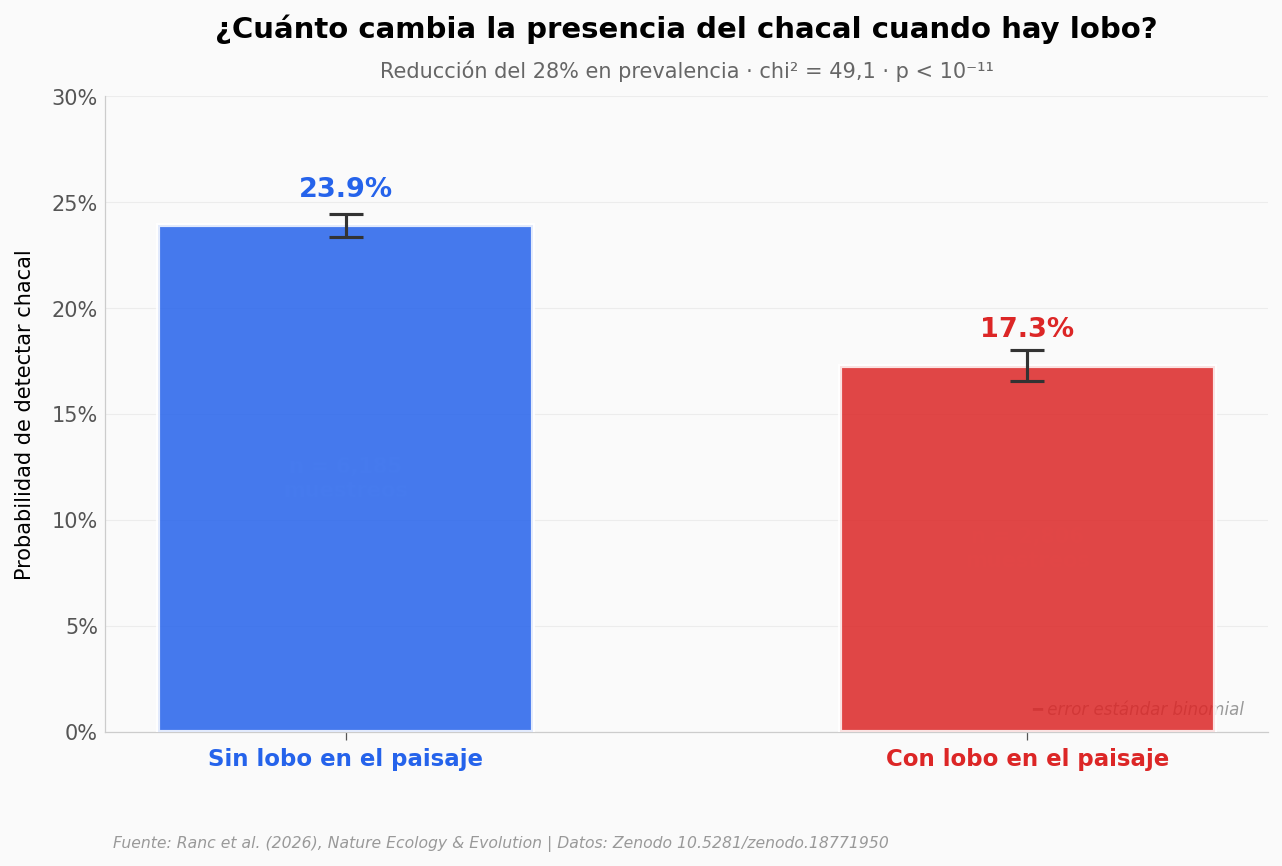

In [2]:
fig, ax = plt.subplots(figsize=(10, 5.5))

labels = ['Sin lobo en el paisaje', 'Con lobo en el paisaje']
prev = por_lobo['jackal_prevalence'].values
se = por_lobo['se'].values
ns = por_lobo['n_surveys'].values
colors = [COLOR_SIN_LOBO, COLOR_CON_LOBO]

x = [0, 1]
bars = ax.bar(x, prev, color=colors, alpha=0.85, width=0.55,
              edgecolor='white', linewidth=2, zorder=4)
ax.errorbar(x, prev, yerr=se, fmt='none', color='#333333',
            capsize=8, capthick=1.5, lw=1.5, zorder=5)

# Etiquetas de valor encima de cada barra
for i, (p, n) in enumerate(zip(prev, ns)):
    ax.text(i, p + 0.011, f'{p:.1%}', ha='center', va='bottom',
            fontsize=13, fontweight='bold', color=colors[i])
    ax.text(i, p / 2, f'n = {n:,}\nmuestreos', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colors):
    tick.set_color(color)

ax.set_ylabel('Probabilidad de detectar chacal', fontsize=10)
ax.set_ylim(0, 0.30)
ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
ax.set_yticklabels(['0%', '5%', '10%', '15%', '20%', '25%', '30%'])

ax.set_title('¿Cuánto cambia la presencia del chacal cuando hay lobo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Reducción del 28% en prevalencia · chi² = 49,1 · p < 10⁻¹¹',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota error bars
ax.text(0.98, 0.02, '━ error estándar binomial', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_hero_jackal_con_sin_lobo.png', dpi=200, bbox_inches='tight')
plt.show()

## Lectura

La diferencia es nítida y muy grande para un estudio con casi nueve mil muestreos: en transectos sin lobo, el chacal aparece en uno de cada cuatro muestreos. En transectos con lobo, baja a uno de cada seis. Es una caída de 7 puntos porcentuales, un 28% menos en términos relativos.

Y no es ruido. Una chi-cuadrado contra la hipótesis de "no hay diferencia" devuelve p < 10⁻¹¹ — la probabilidad de que un patrón así de fuerte salga por azar es astronómicamente baja.

Pero hay un detalle importante: estos son transectos diferentes en lugares diferentes. No es un experimento. El paisaje también cambia: donde hay lobos suele haber más bosque, menos asentamientos. ¿Y si el chacal no estaba huyendo del lobo, sino del bosque?

## Zoom: ¿es el lobo o es el bosque?

Cortamos los muestreos por cantidad de bosque en el paisaje (0-10%, 10-30%, 30-60%, 60-100%) y volvemos a separar entre con-lobo y sin-lobo. Si el chacal se aleja del bosque por su cuenta, debería verse el mismo descenso con o sin lobo. Si el lobo es el factor, el patrón debería cambiar.

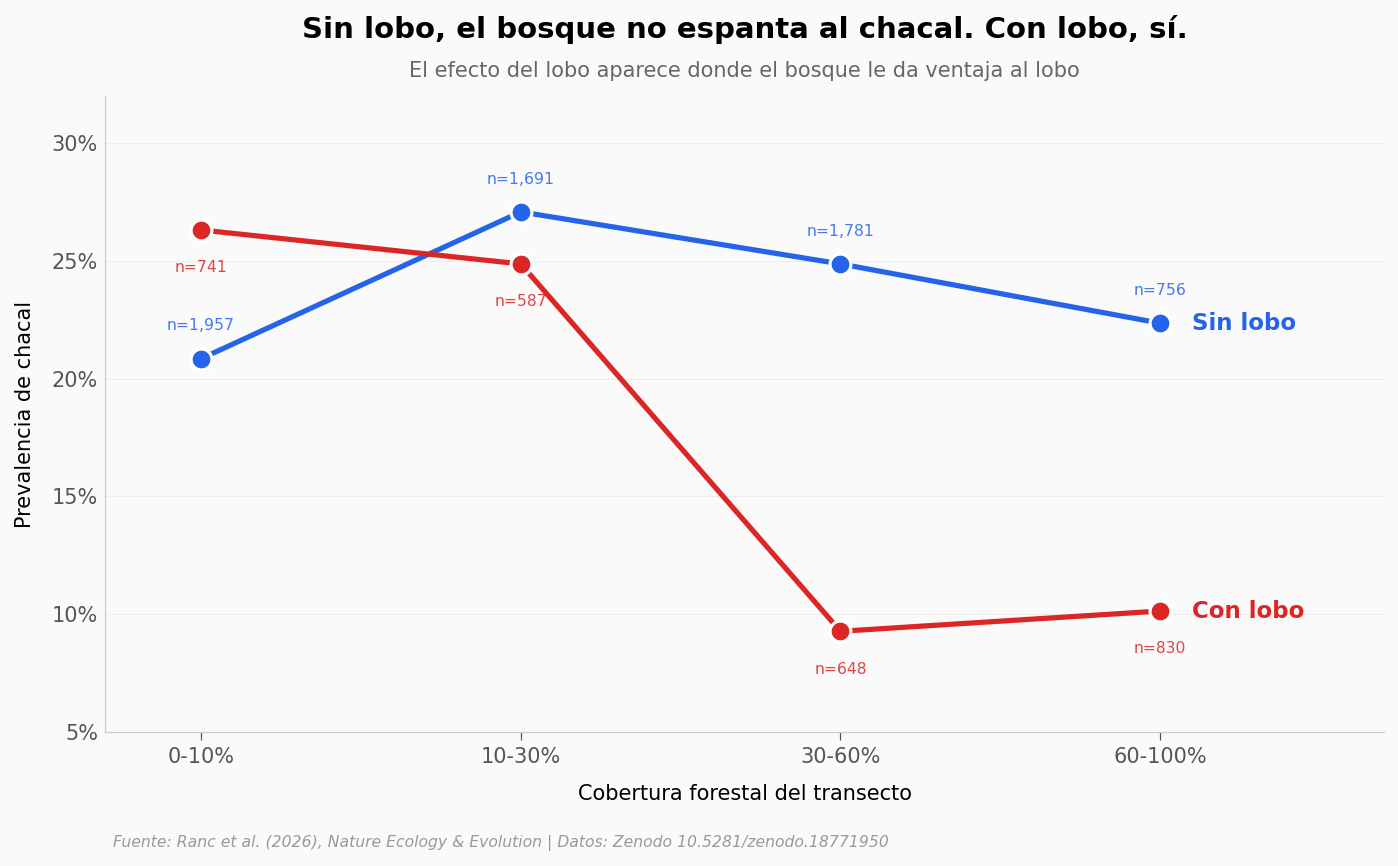

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

bins = ['0-10', '10-30', '30-60', '60-100']
x_pos = np.arange(len(bins))

sin_lobo = wolf_forest[wolf_forest['wolf_label'] == 'sin_lobo'].set_index('forest_bin').loc[bins]
con_lobo = wolf_forest[wolf_forest['wolf_label'] == 'con_lobo'].set_index('forest_bin').loc[bins]

# Líneas con marcadores
ax.plot(x_pos, sin_lobo['jackal'].values, 'o-', color=COLOR_SIN_LOBO,
        linewidth=2.5, markersize=10, markeredgecolor='white',
        markeredgewidth=1.5, zorder=5)
ax.plot(x_pos, con_lobo['jackal'].values, 'o-', color=COLOR_CON_LOBO,
        linewidth=2.5, markersize=10, markeredgecolor='white',
        markeredgewidth=1.5, zorder=5)

# Inline labels (en vez de legend box)
ax.text(3.05, sin_lobo['jackal'].values[-1], '  Sin lobo', fontsize=11,
        color=COLOR_SIN_LOBO, fontweight='bold', va='center', ha='left')
ax.text(3.05, con_lobo['jackal'].values[-1], '  Con lobo', fontsize=11,
        color=COLOR_CON_LOBO, fontweight='bold', va='center', ha='left')

# Anotaciones de n por punto (más discretas)
for i, (s, c) in enumerate(zip(sin_lobo['n'].values, con_lobo['n'].values)):
    ax.text(i, sin_lobo['jackal'].values[i] + 0.012, f'n={s:,}',
            ha='center', fontsize=7.5, color=COLOR_SIN_LOBO, alpha=0.85)
    ax.text(i, con_lobo['jackal'].values[i] - 0.018, f'n={c:,}',
            ha='center', fontsize=7.5, color=COLOR_CON_LOBO, alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'{b}%' for b in bins], fontsize=10)
ax.set_xlabel('Cobertura forestal del transecto', fontsize=10)
ax.set_ylabel('Prevalencia de chacal', fontsize=10)
ax.set_ylim(0.05, 0.32)
ax.set_yticks([0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
ax.set_yticklabels(['5%', '10%', '15%', '20%', '25%', '30%'])
ax.set_xlim(-0.3, 3.7)

ax.set_title('Sin lobo, el bosque no espanta al chacal. Con lobo, sí.',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'El efecto del lobo aparece donde el bosque le da ventaja al lobo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_wolf_x_forest.png', dpi=200, bbox_inches='tight')
plt.show()

## El bosque es el árbitro

Mira la línea azul: sin lobo, la prevalencia del chacal apenas oscila entre 21% y 27% por todo el gradiente forestal. No le importa cuánto bosque haya — el chacal está cómodo en abierto y en arbolado.

La línea roja cuenta otra historia. En paisajes con poco bosque (0-30%), la prevalencia del chacal con y sin lobo es parecida. Pero cuando el bosque cubre más del 30% del transecto, la presencia del chacal con lobo se reduce de ~25% a ~10%.

El patrón es claro a escala de transecto: donde el bosque le da ventaja al lobo (su nicho histórico), el chacal se repliega; en paisajes abiertos la diferencia entre con-lobo y sin-lobo casi desaparece.

## ¿Y entre países? ¿Se reproduce ahí?

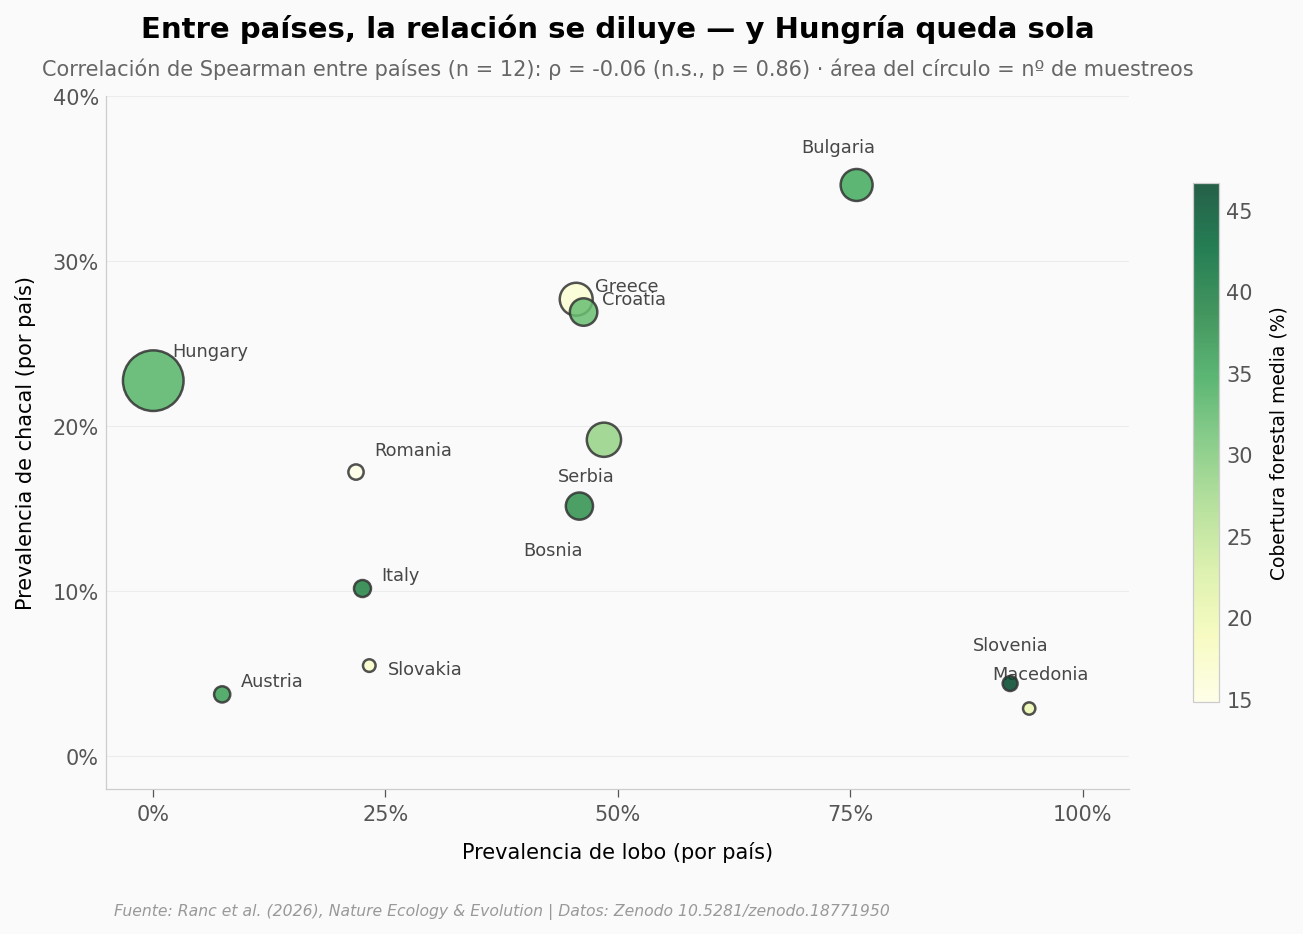

Correlación país-país: ρ = -0.056, p = 0.863


In [4]:
fig, ax = plt.subplots(figsize=(11, 6))

# Color por bin de cobertura forestal media
forest_norm = (por_pais['forest_mean'] - por_pais['forest_mean'].min()) / (
    por_pais['forest_mean'].max() - por_pais['forest_mean'].min())

scatter = ax.scatter(
    por_pais['wolf_prevalence'], por_pais['jackal_prevalence'],
    s=por_pais['n_surveys'] / 4,           # tamaño = nº muestreos
    c=por_pais['forest_mean'], cmap='YlGn',
    edgecolors='#333333', linewidths=1.2, alpha=0.85, zorder=5,
)

# Etiquetas de país (con desplazamiento manual para evitar solape)
offsets = {
    'Hungary': (0.02, 0.015),
    'Serbia': (-0.05, -0.025),
    'Greece': (0.02, 0.005),
    'Bulgaria': (-0.06, 0.020),
    'Croatia': (0.02, 0.005),
    'Bosnia and Herzegovina': (-0.06, -0.030),
    'Italy': (0.02, 0.005),
    'Austria': (0.02, 0.005),
    'Romania': (0.02, 0.010),
    'Slovenia': (-0.04, 0.020),
    'Slovakia': (0.02, -0.005),
    'Macedonia': (-0.04, 0.018),
}
for _, row in por_pais.iterrows():
    dx, dy = offsets.get(row['country'], (0.02, 0.005))
    name = row['country'].replace('Bosnia and Herzegovina', 'Bosnia')
    ax.text(row['wolf_prevalence'] + dx, row['jackal_prevalence'] + dy,
            name, fontsize=8.5, color='#333333', alpha=0.9)

# Línea de tendencia (Spearman es lo que toca aquí — los % por país no son normales)
rho, pval = stats.spearmanr(por_pais['wolf_prevalence'], por_pais['jackal_prevalence'])

ax.set_xlabel('Prevalencia de lobo (por país)', fontsize=10)
ax.set_ylabel('Prevalencia de chacal (por país)', fontsize=10)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.set_yticks([0, 0.10, 0.20, 0.30, 0.40])
ax.set_yticklabels(['0%', '10%', '20%', '30%', '40%'])
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.02, 0.40)

ax.set_title('Entre países, la relación se diluye — y Hungría queda sola',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'Correlación de Spearman entre países (n = 12): ρ = {rho:.2f} (n.s., p = {pval:.2f}) · área del círculo = nº de muestreos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

cbar = plt.colorbar(scatter, ax=ax, shrink=0.75)
cbar.set_label('Cobertura forestal media (%)', fontsize=9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_por_pais.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Correlación país-país: ρ = {rho:.3f}, p = {pval:.3f}')

## El dato menos confortable

Hay una excepción enorme en el gráfico anterior: Hungría. **3.385 muestreos — el 38% del dataset** — y prácticamente sin lobos detectados (0,06% de prevalencia). En ese refugio sin lobos, la prevalencia del chacal sube a 22,7%.

Hungría es el "experimento natural" que el resto de Europa quizá esté a punto de repetir. ¿Y si comparamos su prevalencia contra la distribución de todos los demás países?

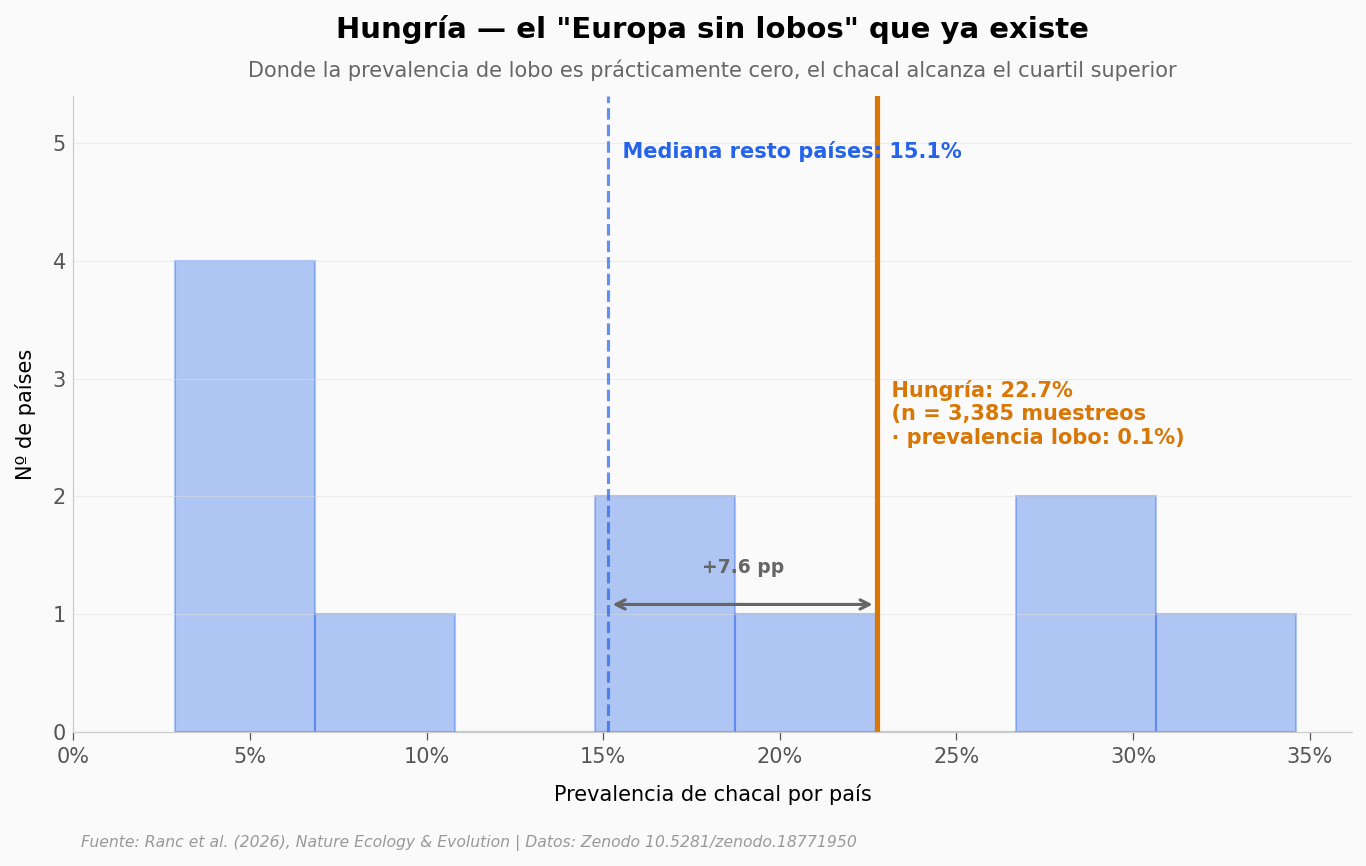

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Excluir Hungría del histograma para ver la referencia
otros = por_pais[por_pais['country'] != 'Hungary'].copy()
hungria = por_pais[por_pais['country'] == 'Hungary'].iloc[0]

n_bins = 8
n, bins, patches = ax.hist(otros['jackal_prevalence'], bins=n_bins,
                           color=COLOR_SIN_LOBO, alpha=0.35,
                           edgecolor=COLOR_SIN_LOBO, linewidth=1.0)

y_max = n.max() * 1.35
ax.set_ylim(0, y_max)

mediana_otros = otros['jackal_prevalence'].median()

# Mediana del resto de países
ax.axvline(mediana_otros, color=COLOR_SIN_LOBO, linewidth=1.5,
           linestyle='--', alpha=0.7)
ax.text(mediana_otros, y_max * 0.93, f'  Mediana resto países: {mediana_otros:.1%}',
        color=COLOR_SIN_LOBO, fontsize=10, fontweight='bold', va='top')

# Hungría
ax.axvline(hungria['jackal_prevalence'], color=COLOR_DESTACAR, linewidth=2.5)
ax.text(hungria['jackal_prevalence'], y_max * 0.50,
        f'  Hungría: {hungria["jackal_prevalence"]:.1%}\n  (n = {int(hungria["n_surveys"]):,} muestreos\n  · prevalencia lobo: {hungria["wolf_prevalence"]:.1%})',
        color=COLOR_DESTACAR, fontsize=10, fontweight='bold', va='center')

# Flecha bidireccional entre mediana y Hungría
ax.annotate('', xy=(hungria['jackal_prevalence'], y_max * 0.20),
            xytext=(mediana_otros, y_max * 0.20),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = hungria['jackal_prevalence'] - mediana_otros
ax.text((mediana_otros + hungria['jackal_prevalence']) / 2, y_max * 0.25,
        f'+{diff*100:.1f} pp',
        ha='center', fontsize=9, color='#666666', fontweight='bold')

ax.set_xlabel('Prevalencia de chacal por país', fontsize=10)
ax.set_ylabel('Nº de países', fontsize=10)
ax.set_xticks([0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35])
ax.set_xticklabels(['0%', '5%', '10%', '15%', '20%', '25%', '30%', '35%'])

ax.set_title('Hungría — el "Europa sin lobos" que ya existe',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Donde la prevalencia de lobo es prácticamente cero, el chacal alcanza el cuartil superior',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_hungria_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

Antes de cerrar, cruzamos cada afirmación del paper contra los datos crudos que acabamos de explorar.

| Afirmación | ¿Soportada? | Detalle |
|---|:-:|---|
| El lobo es el principal factor que limita la presencia del chacal | ✅ | Datos crudos: 23,9% sin lobo → 17,3% con lobo. Chi² = 49,1, p < 10⁻¹¹. El paper lo confirma con un modelo que controla por bosque, clima y nieve. |
| El efecto del lobo aparece sobre todo en hábitats forestales | ✅ | Con > 30% bosque, chacal baja de ~25% a ~10% cuando hay lobo. En paisajes abiertos (0-30% bosque), el efecto se diluye. |
| Los humanos actúan como "escudo" reduciendo la supresión del lobo | ⚠️ | El paper lo deriva de un modelo SDM con interacciones; el gradiente bivariado dist_human × wolf en el CSV crudo no lo muestra de forma evidente. Lo citamos como conclusión del modelo, no del scatter directo. |
| El chacal podría ocupar el 75% de Europa, ~6× su rango actual; recuperar al lobo podría reducir esa expansión hasta un 18% | ✅ (cita) | Outputs del modelo de Ranc et al. — no recomputables desde los 8.991 muestreos. Son proyecciones bajo escenarios climáticos y de cobertura del lobo. |

> **Limitaciones:** el dataset es observacional, no experimental — la causalidad lobo → menos chacal viene del peso conjunto de modelo y biología, no de un solo análisis. Hungría aporta el 38% de los muestreos, así que algunos promedios globales están dominados por un país. Los porcentajes "75%", "6×" y "18%" son proyecciones del modelo SDM (Species Distribution Model) ajustado por Ranc et al., no estadísticos descriptivos de los datos crudos.

## Ahora tú

1. **¿Cuánto cambia la prevalencia del chacal en Hungría si quitas los muestreos rurales más alejados de humanos?** (Pista: filtra `surveys[surveys['country'] == 'Hungary']` y crúzalo por quintil de `dist_human`.)

2. **¿En qué países el chacal aparece más donde hay menos bosque?** (Pista: agrupa `surveys` por país y por bin de `forest`, calcula prevalencia.)

3. **¿La nieve tiene efecto sobre la presencia del chacal?** (Pista: el chacal dorado es de origen subtropical — ¿qué pasa cuando agrupas por bins de `snow`?)

Prevalencia del chacal por cuartil de nieve:
  Q1 (menos nieve): 26.0%  (n = 2,249)
  Q2: 28.8%  (n = 2,247)
  Q3: 21.2%  (n = 2,247)
  Q4 (más nieve): 11.3%  (n = 2,248)


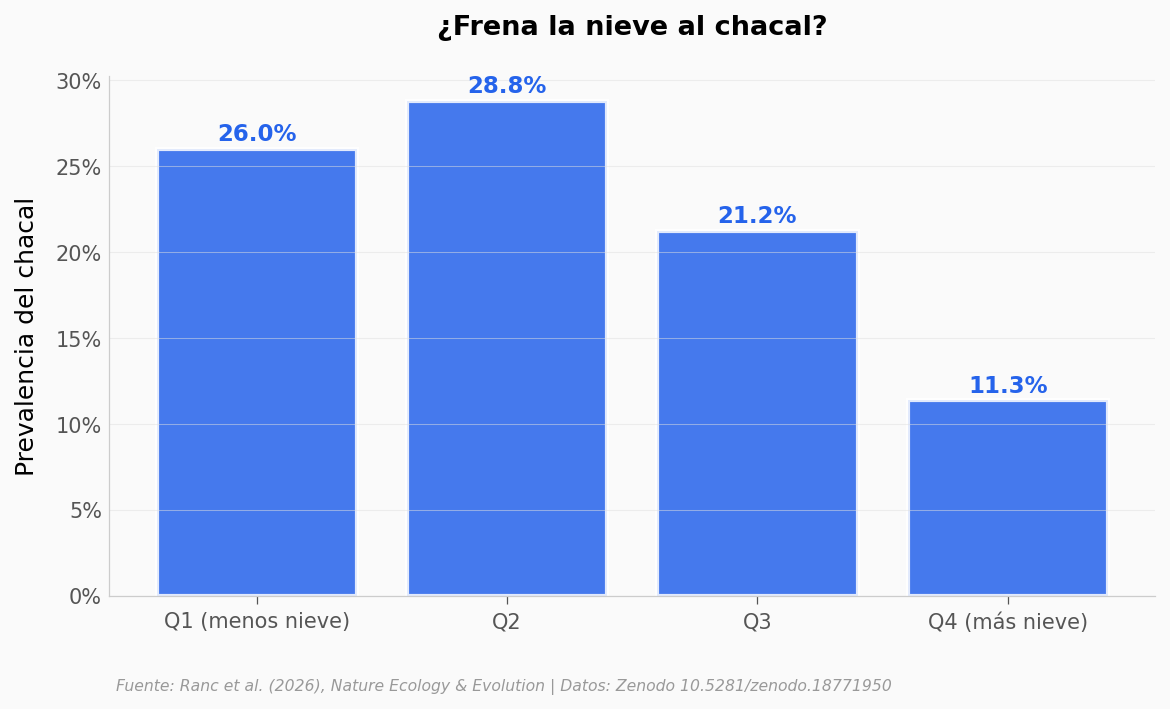

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Respuesta sugerida a la pregunta 3: ¿la nieve frena al chacal?

# Bins de nieve (la variable está escalada en el dataset, pero podemos
# percentilarla para comparar entre cuartiles)
surveys['snow_q'] = pd.qcut(surveys['snow'], q=4,
                            labels=['Q1 (menos nieve)', 'Q2', 'Q3', 'Q4 (más nieve)'])
snow_tab = surveys.groupby('snow_q', observed=True).agg(
    n_surveys=('presence', 'size'),
    jackal_prev=('presence', 'mean'),
).reset_index()

print('Prevalencia del chacal por cuartil de nieve:')
for _, row in snow_tab.iterrows():
    print(f"  {row['snow_q']}: {row['jackal_prev']:.1%}  (n = {int(row['n_surveys']):,})")

# Visualización rápida
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(snow_tab['snow_q'].astype(str), snow_tab['jackal_prev'],
       color=[COLOR_SIN_LOBO]*4, alpha=0.85, edgecolor='white', linewidth=2)
for i, p in enumerate(snow_tab['jackal_prev']):
    ax.text(i, p + 0.005, f'{p:.1%}', ha='center', fontweight='bold',
            color=COLOR_SIN_LOBO, fontsize=11)
ax.set_ylabel('Prevalencia del chacal')
ax.set_yticks([0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30])
ax.set_yticklabels(['0%', '5%', '10%', '15%', '20%', '25%', '30%'])
ax.set_title('¿Frena la nieve al chacal?', fontsize=13, fontweight='bold', pad=20)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/05_experimento_nieve.png', dpi=200, bbox_inches='tight')
plt.show()

---

## Fuentes

**Paper**: [Human shielding from wolves facilitates jackal expansion across Europe](https://doi.org/10.1038/s41559-026-03060-y)  
*Nature Ecology & Evolution, 2026-02-25*

**Datos**: [Zenodo — Ranc et al. 2026 dataset and code](https://doi.org/10.5281/zenodo.18771950)

**Referencias citadas**: [Kaczensky et al. 2022 — Distribution of large carnivores in Europe](https://doi.org/10.5061/dryad.pc866t1p3)

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

**Licencia:** CC-BY-4.0 · datos originales bajo licencia Zenodo (CC-BY-4.0)
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)